### Task 
####    Build a regression model to predict food delivery time.
### Goal 
   #### Estimate the delivery time in minutes using order, restaurant, and delivery partner information so Porter can provide customers with an accurate expected delivery time.

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [109]:
df = pd.read_csv('dataset.csv')

In [110]:
df.head(5)

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0


### Understand the Dataset (EDA)

In [111]:
df.shape

(197428, 14)

In [112]:
df.columns

Index(['market_id', 'created_at', 'actual_delivery_time', 'store_id',
       'store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_partners', 'total_busy_partners',
       'total_outstanding_orders'],
      dtype='object')

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 196441 non-null  float64
 1   created_at                197428 non-null  object 
 2   actual_delivery_time      197421 non-null  object 
 3   store_id                  197428 non-null  object 
 4   store_primary_category    192668 non-null  object 
 5   order_protocol            196433 non-null  float64
 6   total_items               197428 non-null  int64  
 7   subtotal                  197428 non-null  int64  
 8   num_distinct_items        197428 non-null  int64  
 9   min_item_price            197428 non-null  int64  
 10  max_item_price            197428 non-null  int64  
 11  total_onshift_partners    181166 non-null  float64
 12  total_busy_partners       181166 non-null  float64
 13  total_outstanding_orders  181166 non-null  f

In [114]:
df.describe()

,market_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
count,196441.000000,196433.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,181166.000000,181166.000000,181166.000000
mean,2.978706,2.882352,3.196391,2682.331402,2.670791,686.218470,1159.588630,44.808093,41.739747,58.050065
std,1.524867,1.503771,2.666546,1823.093688,1.630255,522.038648,558.411377,34.526783,32.145733,52.661830
min,1.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000
25%,2.000000,1.000000,2.000000,1400.000000,1.000000,299.000000,800.000000,17.000000,15.000000,17.000000
50%,3.000000,3.000000,3.000000,2200.000000,2.000000,595.000000,1095.000000,37.000000,34.000000,41.000000
75%,4.000000,4.000000,4.000000,3395.000000,3.000000,949.000000,1395.000000,65.000000,62.000000,85.000000
max,6.000000,7.000000,411.000000,27100.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000


In [115]:
df.tail()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
197423,1.0,2015-02-17 00:19:41,2015-02-17 01:24:48,a914ecef9c12ffdb9bede64bb703d877,fast,4.0,3,1389,3,345,649,17.0,17.0,23.0
197424,1.0,2015-02-13 00:01:59,2015-02-13 00:58:22,a914ecef9c12ffdb9bede64bb703d877,fast,4.0,6,3010,4,405,825,12.0,11.0,14.0
197425,1.0,2015-01-24 04:46:08,2015-01-24 05:36:16,a914ecef9c12ffdb9bede64bb703d877,fast,4.0,5,1836,3,300,399,39.0,41.0,40.0
197426,1.0,2015-02-01 18:18:15,2015-02-01 19:23:22,c81e155d85dae5430a8cee6f2242e82c,sandwich,1.0,1,1175,1,535,535,7.0,7.0,12.0
197427,1.0,2015-02-08 19:24:33,2015-02-08 20:01:41,c81e155d85dae5430a8cee6f2242e82c,sandwich,1.0,4,2605,4,425,750,20.0,20.0,23.0


In [116]:
df.isnull().sum()

market_id                     987
created_at                      0
actual_delivery_time            7
store_id                        0
store_primary_category       4760
order_protocol                995
total_items                     0
subtotal                        0
num_distinct_items              0
min_item_price                  0
max_item_price                  0
total_onshift_partners      16262
total_busy_partners         16262
total_outstanding_orders    16262
dtype: int64

### Data Preprocessing

In [117]:
df.duplicated().sum()

np.int64(0)

In [118]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

##### creating the target column delivery time in minutes 

In [119]:
#Why use .dt?
#.dt is used to access datetime properties of a pandas Series.
df['delivery_time'] = (
    df['actual_delivery_time'] - df['created_at']
).dt.total_seconds() / 60 


In [120]:
df['order_hour'] = df['created_at'].dt.hour

In [121]:
df['order_day'] = df['created_at'].dt.day_name()

In [122]:
df[["created_at", "actual_delivery_time", "delivery_time", "order_hour", "order_day"]].head()

,created_at,actual_delivery_time,delivery_time,order_hour,order_day
0,2015-02-06 22:24:17,2015-02-06 23:27:16,62.983333,22,Friday
1,2015-02-10 21:49:25,2015-02-10 22:56:29,67.066667,21,Tuesday
2,2015-01-22 20:39:28,2015-01-22 21:09:09,29.683333,20,Thursday
3,2015-02-03 21:21:45,2015-02-03 22:13:00,51.250000,21,Tuesday
4,2015-02-15 02:40:36,2015-02-15 03:20:26,39.833333,2,Sunday


### Handle Missing Values

In [123]:
df.isnull().sum()

market_id                     987
created_at                      0
actual_delivery_time            7
store_id                        0
store_primary_category       4760
order_protocol                995
total_items                     0
subtotal                        0
num_distinct_items              0
min_item_price                  0
max_item_price                  0
total_onshift_partners      16262
total_busy_partners         16262
total_outstanding_orders    16262
delivery_time                   7
order_hour                      0
order_day                       0
dtype: int64

In [124]:
df['market_id'] = df['market_id'].fillna(df['market_id'].mode()[0])

In [125]:
df["store_primary_category"] = df["store_primary_category"].fillna(df["store_primary_category"].mode()[0])

In [126]:
df["order_protocol"] = df["order_protocol"].fillna(df["order_protocol"].mode()[0])

In [127]:
df["total_onshift_partners"] = df["total_onshift_partners"].fillna(df["total_onshift_partners"].median())

In [128]:
df["total_busy_partners"] = df["total_busy_partners"].fillna(df["total_busy_partners"].median())

In [129]:
df["total_outstanding_orders"] = df["total_outstanding_orders"].fillna(df["total_outstanding_orders"].median())

In [130]:
df = df.dropna(subset=["actual_delivery_time"]).copy()

In [131]:
df.isnull().sum()

market_id                   0
created_at                  0
actual_delivery_time        0
store_id                    0
store_primary_category      0
order_protocol              0
total_items                 0
subtotal                    0
num_distinct_items          0
min_item_price              0
max_item_price              0
total_onshift_partners      0
total_busy_partners         0
total_outstanding_orders    0
delivery_time               0
order_hour                  0
order_day                   0
dtype: int64

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197421 entries, 0 to 197427
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   market_id                 197421 non-null  float64       
 1   created_at                197421 non-null  datetime64[ns]
 2   actual_delivery_time      197421 non-null  datetime64[ns]
 3   store_id                  197421 non-null  object        
 4   store_primary_category    197421 non-null  object        
 5   order_protocol            197421 non-null  float64       
 6   total_items               197421 non-null  int64         
 7   subtotal                  197421 non-null  int64         
 8   num_distinct_items        197421 non-null  int64         
 9   min_item_price            197421 non-null  int64         
 10  max_item_price            197421 non-null  int64         
 11  total_onshift_partners    197421 non-null  float64       
 12  total_b

### Encode Categorical Columns

In [133]:
df.select_dtypes(include="object").columns

Index(['store_id', 'store_primary_category', 'order_day'], dtype='object')

In [134]:
from sklearn.preprocessing import LabelEncoder

In [135]:
le = LabelEncoder()

In [136]:
df["store_primary_category"] = le.fit_transform(df["store_primary_category"])
df["order_day"] = le.fit_transform(df["order_day"])

In [137]:
df.head(5)

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_time,order_hour,order_day
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,62.983333,22,0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,47,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,67.066667,21,5
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,4,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,29.683333,20,4
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,4,1.0,6,6900,5,600,1800,1.0,1.0,2.0,51.250000,21,5
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,4,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,39.833333,2,3


### Data Visualization and Cleaning

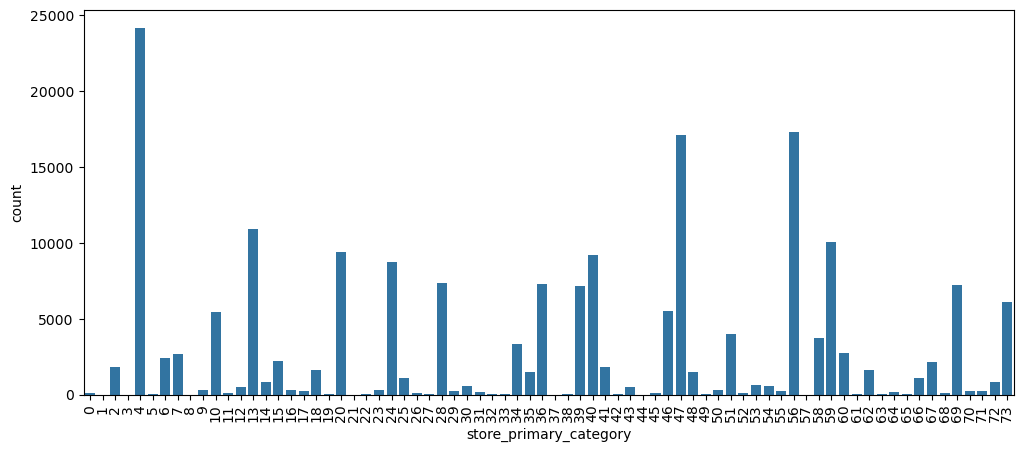

In [138]:
plt.figure(figsize=(12,5))
sns.countplot(x='store_primary_category', data=df)
plt.xticks(rotation=90)
plt.show()
# By this we can know the frequency of each restaurant category            

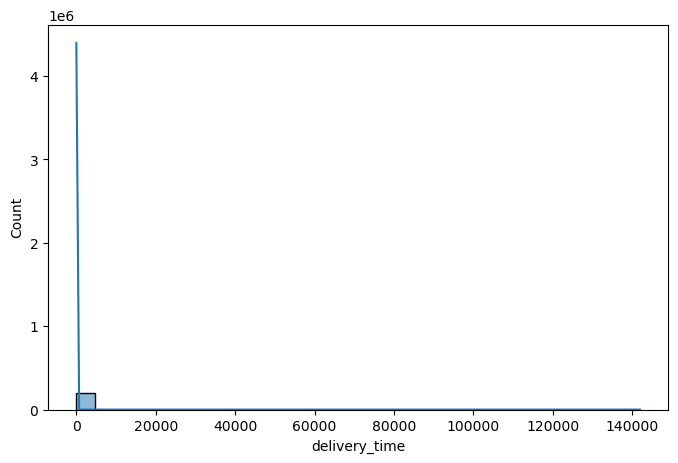

In [139]:
plt.figure(figsize=(8,5))
sns.histplot(df['delivery_time'],bins=30,kde=True)
plt.show()
#It shows how order amounts are distributed

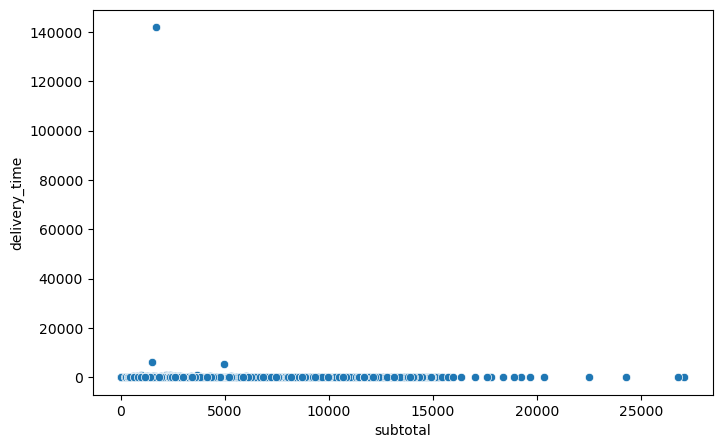

In [140]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='subtotal',y='delivery_time',data=df)
plt.show()
# It tells the relationship between order amount and delivery time

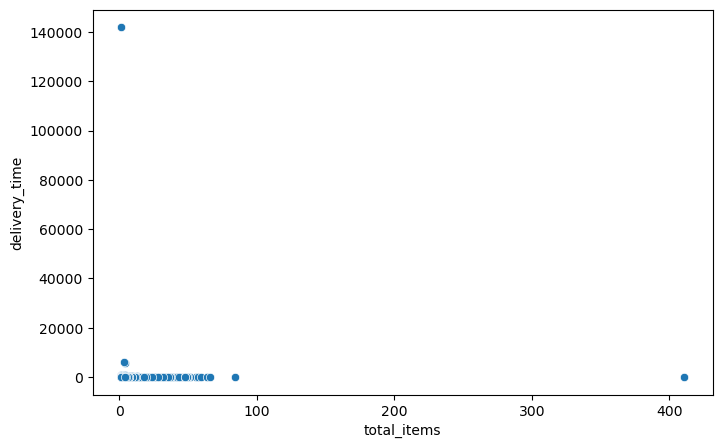

In [141]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="total_items", y="delivery_time", data=df)
plt.show()
# Checks whether more items affect delivery time.

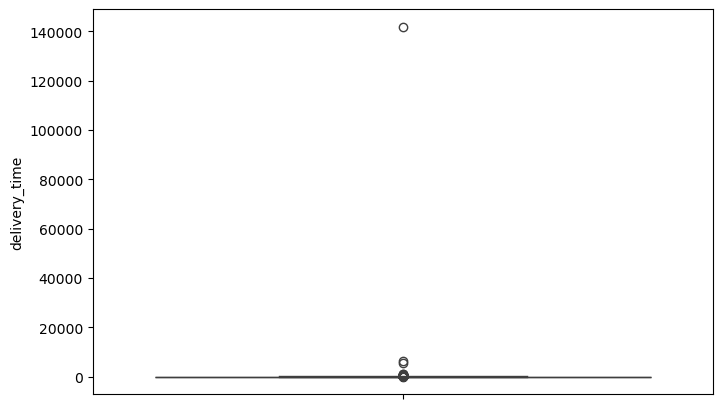

In [142]:
plt.figure(figsize=(8,5))
sns.boxplot(y="delivery_time", data=df)
plt.show()
# It Detects outliers in delivery time.

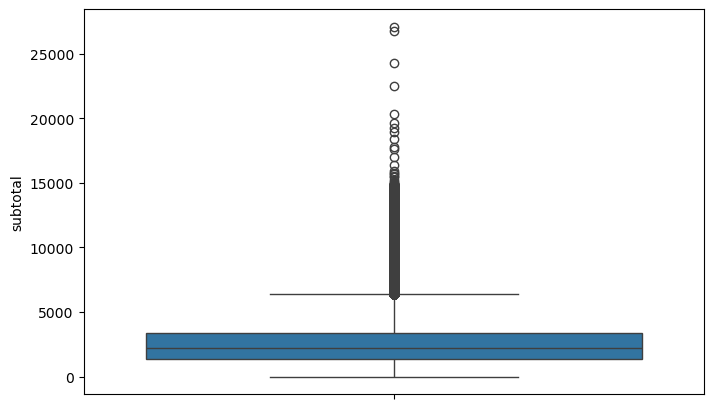

In [143]:
plt.figure(figsize=(8,5))
sns.boxplot(y="subtotal", data=df)
plt.show()
# Detects outliers in order amount.

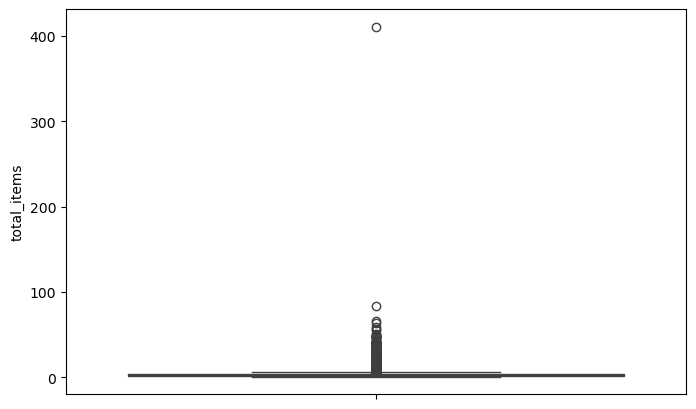

In [144]:
plt.figure(figsize=(8,5))
sns.boxplot(y="total_items", data=df)
plt.show()
# Detects outliers in the number of items.

In [145]:
Q1 = df["delivery_time"].quantile(0.25)
Q3 = df["delivery_time"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [146]:
df = df[(df["delivery_time"] >= lower) & (df["delivery_time"] <= upper)]

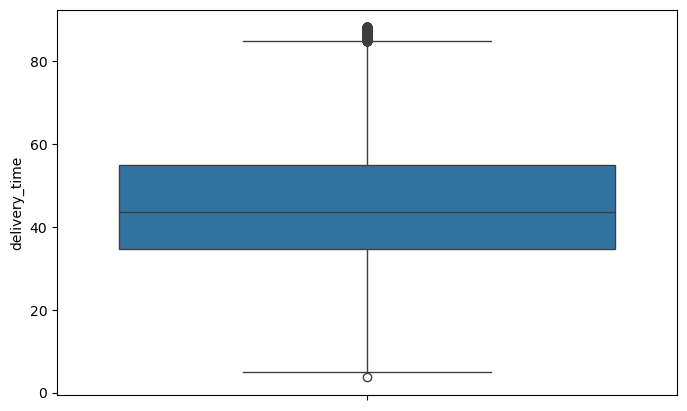

In [147]:
plt.figure(figsize=(8,5))
sns.boxplot(y="delivery_time", data=df)
plt.show()

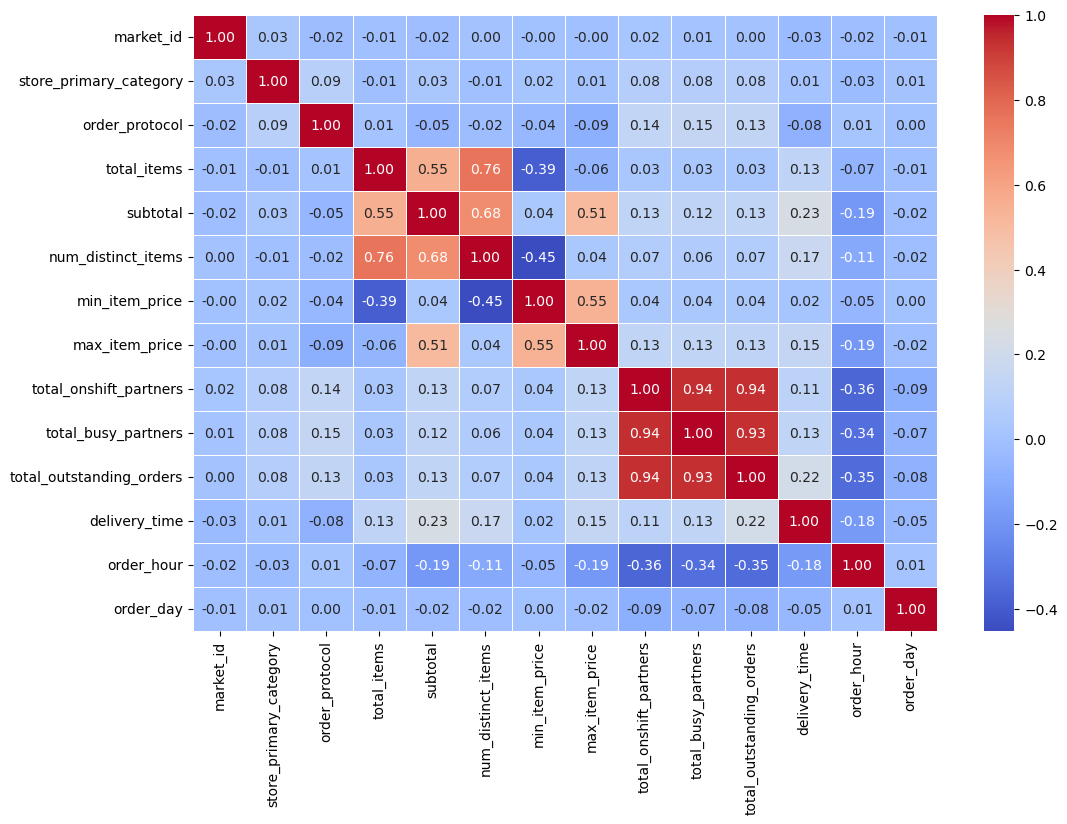

In [148]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.show()

In [149]:
df.columns

Index(['market_id', 'created_at', 'actual_delivery_time', 'store_id',
       'store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_partners', 'total_busy_partners',
       'total_outstanding_orders', 'delivery_time', 'order_hour', 'order_day'],
      dtype='object')

In [150]:

# STEP 1: Drop Unnecessary Columns

df = df.drop(columns=["store_id", "created_at", "actual_delivery_time"])



# STEP 2: Define Features (X) and Target (y)

X = df.drop(columns=["delivery_time"])
y = df["delivery_time"]

# STEP 3: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# STEP 4: Build Linear Regression Model

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)


# STEP 5: Make Predictions

y_pred = lr.predict(X_test)


# STEP 6: Evaluate the Model


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("="*40)
print("Linear Regression Model Performance")
print("="*40)

print(f"MAE      : {mae:.2f}")
print(f"MSE      : {mse:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")


# STEP 7: Train vs Test Score


train_r2 = lr.score(X_train, y_train)
test_r2 = lr.score(X_test, y_test)

print("\n" + "="*40)
print("Train vs Test Performance")
print("="*40)

print(f"Train R² Score : {train_r2:.4f}")
print(f"Test R² Score  : {test_r2:.4f}")

Linear Regression Model Performance
MAE      : 10.63
MSE      : 178.49
RMSE     : 13.36
R² Score : 0.1803

Train vs Test Performance
Train R² Score : 0.1835
Test R² Score  : 0.1803


##### The Linear Regression model achieved an MAE of 10.63 minutes, indicating that predictions differ from actual delivery times by about 10.6 minutes on average. The RMSE of 13.36 minutes suggests that some larger prediction errors are present. The R² score of 0.18 shows that the model explains approximately 18% of the variation in delivery time, indicating that while it captures some trends, much of the variability is influenced by factors not included in the dataset.
# ---
##### The training and testing R² scores are very similar (0.1835 and 0.1803), indicating that the model generalizes well without overfitting. However, the relatively low R² suggests that the Linear Regression model underfits the data and additional features or more complex models may be required to improve predictive performance.

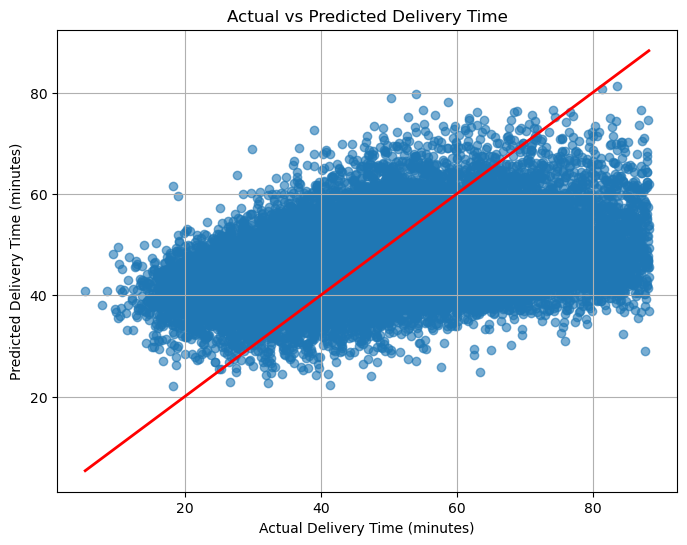

In [155]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time")

plt.grid(True)
plt.show()

##### The Actual vs Predicted plot shows a positive relationship between the actual and predicted delivery times, indicating that the Linear Regression model captures the overall trend. However, the predictions are widely scattered around the ideal diagonal line, suggesting moderate prediction errors. The model also tends to underestimate higher delivery times and overestimate lower delivery times, which is consistent with the relatively low R² score (0.18).

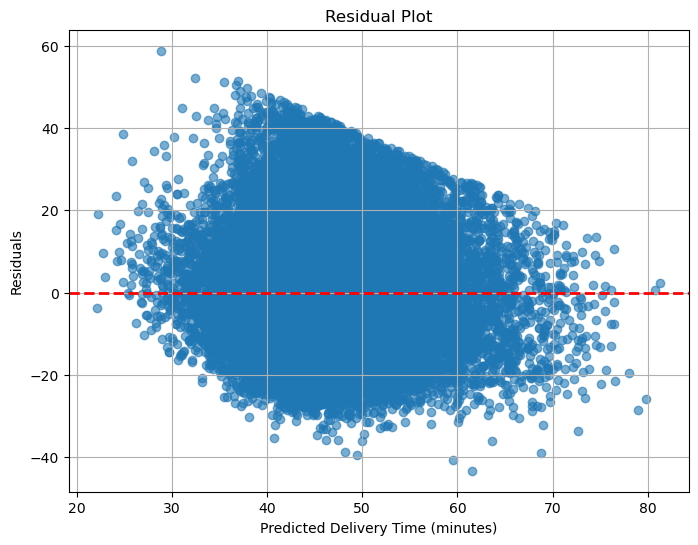

In [156]:
# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.6)

# Horizontal reference line at zero
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Predicted Delivery Time (minutes)")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)
plt.show()

###### The residuals are mostly spread around the zero line, which means the model does not consistently overpredict or underpredict the delivery time. However, the points are not completely random and show some spread, indicating that the Linear Regression model cannot capture all the patterns in the data. This matches the low R² score of 0.18.

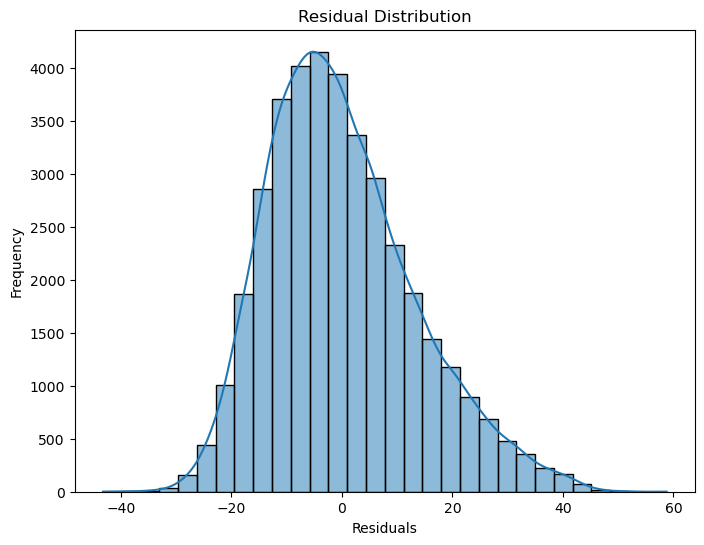

In [157]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.show()

###### The residuals are approximately normally distributed and centered around zero, indicating that the model's prediction errors are generally balanced. Although there is a slight right skew, the overall distribution supports the assumptions of Linear Regression.

In [158]:
# Create a DataFrame of feature coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

# Sort coefficients from highest to lowest
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
5,num_distinct_items,0.423078
10,total_outstanding_orders,0.283684
4,subtotal,0.001289
1,store_primary_category,0.001048
7,max_item_price,0.000585
6,min_item_price,0.000197
3,total_items,-0.025545
9,total_busy_partners,-0.091381
11,order_hour,-0.190954
0,market_id,-0.237335


##### The coefficient analysis shows that num_distinct_items and total_outstanding_orders have the strongest positive influence on delivery time, indicating that larger and busier orders generally take longer to deliver. On the other hand, order_protocol and total_onshift_partners have the strongest negative influence, suggesting that efficient ordering methods and greater partner availability help reduce delivery time. Some variables, such as subtotal, min_item_price, and max_item_price, have coefficients close to zero, indicating only a minor impact on the model's predictions.

## Final Conclusion

#### This project aimed to predict food delivery time using a Linear Regression model based on order, store, and partner-related features. The dataset was preprocessed by handling missing values, removing outliers, encoding categorical variables, and performing feature engineering. Exploratory Data Analysis (EDA) was conducted to understand the relationships between variables using statistical summaries and visualization techniques.

#### The Linear Regression model achieved an MAE of 10.63 minutes, an RMSE of 13.36 minutes, and an R² score of 0.18. The training and testing R² scores were very similar, indicating that the model generalizes well and does not suffer from overfitting. However, the relatively low R² score suggests that the available features explain only a portion of the variation in delivery time.

#### Coefficient analysis showed that num_distinct_items and total_outstanding_orders had the strongest positive influence on delivery time, while order_protocol and total_onshift_partners had the strongest negative influence. Residual analysis indicated that the prediction errors were generally centered around zero and approximately normally distributed, supporting the assumptions of Linear Regression, although some prediction errors remained due to the limited explanatory power of the available features.

#### Overall, the Linear Regression model provides a simple and interpretable baseline for predicting delivery time. While its predictive performance is moderate, it offers valuable business insights into the factors affecting delivery time and can serve as a foundation for developing more advanced predictive models in the future.